In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import utulek

utulek.platform.import_globals_notebook(globals())

base_module = utulek


I0000 00:00:1785182896.367338  789147 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785182896.373077  789147 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1785182898.976466  789147 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785182898.979076  789147 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


IS_NOTEBOOK_KERNEL_CODE = True
NOTEBOOK_NAME = 2026_07_27-t2i.1.ipynb
ASSET_PATH = /home/gilgamesh/main.syncthing/utulek/experiment/2026_07_27-t2i.ipynb.asset/
Loaded `/home/gilgamesh/main.syncthing/utulek/experiment/.env`.
torch: []
tf: 
jax: [CpuDevice(id=0)]


E0000 00:00:1785182902.208963  789147 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
from diffusers import ModularPipeline, AnimaModularPipeline, ComponentsManager, AnimaAutoBlocks

Modular Diffusers is currently an experimental feature under active development. The API is subject to breaking changes in future releases.


In [4]:
repo_id = "circlestone-labs/Anima-Base-v1.0-Diffusers"
device = "cpu"

model = AnimaModularPipeline.from_pretrained(repo_id)
model.load_components(torch_dtype=torch.bfloat16)
model.to("cpu")
torch.cuda.empty_cache()

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


modular_model_index.json:   0%|          | 0.00/2.41k [00:00<?, ?B/s]

Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.
/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


tokenizer_config.json:   0%|          | 0.00/421 [00:00<?, ?B/s]

tokenizer/tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

...

text_conditioner/diffusion_pytorch_model(…): reconstructing file:   0%|          |  0.00B /  269MB            

text_conditioner/diffusion_pytorch_model(…): downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

transformer/diffusion_pytorch_model.safe(…): reconstructing file:   0%|          |  0.00B / 3.91GB            

transformer/diffusion_pytorch_model.safe(…): downloading bytes:           |  0.00B            

In [5]:
blocks = model.blocks
blocks

AnimaAutoBlocks(
  Class: SequentialPipelineBlocks

  Description: Auto Modular pipeline for text-to-image and image-to-image generation using Anima.
      
      Supported workflows:
        - `text2image`: requires `prompt`
        - `img2img`: requires `image`, `prompt`


  Components:
      text_encoder (`Qwen3Model`)
      tokenizer (`Qwen2Tokenizer`)
      t5_tokenizer (`T5Tokenizer`)
      guider (`ClassifierFreeGuidance`)
      vae (`AutoencoderKLQwenImage`)
      image_processor (`VaeImageProcessor`)
      text_conditioner (`AnimaTextConditioner`)
      transformer (`CosmosTransformer3DModel`)
      scheduler (`FlowMatchEulerDiscreteScheduler`)

  Sub-Blocks:
    [0] text_encoder (AnimaTextEncoderStep)
       Description: Text encoder step that encodes Anima prompts into Qwen states and T5 token ids.

    [1] vae_encoder (AnimaAutoVaeImageEncoderStep)
       Description: VAE Image Encoder step that encodes the input image to produce image_latents. Skipped when no image is prov

In [6]:
b0 = blocks.sub_blocks["text_encoder"]
b0

AnimaTextEncoderStep {
  "_class_name": "AnimaTextEncoderStep",
  "_diffusers_version": "0.40.0.dev0"
}

In [7]:
b0p = b0.init_pipeline(repo_id)
b0p.load_components(torch_dtype=torch.bfloat16)

Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.


Loading weights:   0%|          | 0/310 [00:00<?, ?it/s]

In [22]:
b0p.to(device)
b0po = b0p(
	prompt="masterpiece, 1girl, nsfw, emilia, re zero")
b0po

PipelineState(
  values={
    prompt: 'masterpiece, 1girl, nsfw, emilia, re zero'
    negative_prompt: None
    max_sequence_length: 512
    qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 15, 1024]))
    qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 15]))
    t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 20]))
    t5_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 20]))
    negative_qwen_prompt_embeds: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 1, 1024]))
    negative_qwen_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 1]))
    negative_t5_input_ids: Tensor(dtype=torch.int64, shape=torch.Size([1, 1]))
    negative_t5_attention_mask: Tensor(dtype=torch.int64, shape=torch.Size([1, 1]))
  },
  kwargs_mapping={

  }
)

In [23]:
b0p.to("cpu")
torch.cuda.empty_cache()

In [24]:
b1 = blocks.sub_blocks["denoise"]
b1

AnimaAutoCoreDenoiseStep(
  Class: AutoPipelineBlocks

  This pipeline contains blocks that are selected at runtime based on inputs.
  Trigger Inputs: ['image_latents']


  Description: Denoise step that selects between text-to-image and image-to-image denoising based on whether image_latents is present in state. - `AnimaCoreDenoiseStep` (text2image) is used when no image_latents are present. - `AnimaImg2ImgCoreDenoiseStep` (img2img) is used when image_latents are present.


  Components:
      text_conditioner (`AnimaTextConditioner`)
      transformer (`CosmosTransformer3DModel`)
      scheduler (`FlowMatchEulerDiscreteScheduler`)
      guider (`ClassifierFreeGuidance`)

  Sub-Blocks:
    • img2img (AnimaImg2ImgCoreDenoiseStep)
       Description: Denoise block for Anima image-to-image generation. Uses image_latents already in state from AnimaImg2ImgVaeEncoderStep.

    • text2image [default] (AnimaCoreDenoiseStep)
       Description: Denoise block that takes encoded Anima text input

In [25]:
b1p = b1.init_pipeline(repo_id)
b1p.load_components(torch_dtype=torch.bfloat16)
b1p

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(
Guiders are currently an experimental feature under active development. The API is subject to breaking changes in future releases.
/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/diffusers/utils/deprecation_utils.py:23: FutureWarning: `torch_dtype` is deprecated and will be removed in version 1.0.0. Please use `dtype` instead.
  deprecate("torch_dtype", "1.0.0", _TORCH_DTYPE_DEPRECATION_MESSAGE)


AnimaModularPipeline {
  "_blocks_class_name": "AnimaAutoCoreDenoiseStep",
  "_class_name": "AnimaModularPipeline",
  "_diffusers_version": "0.40.0.dev0",
  "scheduler": [
    "diffusers",
    "FlowMatchEulerDiscreteScheduler",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "scheduler",
      "type_hint": [
        "diffusers",
        "FlowMatchEulerDiscreteScheduler"
      ],
      "variant": null
    }
  ],
  "text_conditioner": [
    "diffusers",
    "AnimaTextConditioner",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "text_conditioner",
      "type_hint": [
        "diffusers",
        "AnimaTextConditioner"
      ],
      "variant": null
    }
  ],
  "transformer": [
    "diffusers",
    "CosmosTransformer3DModel",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
  

In [26]:
type(b1p).default_height = property(lambda self: 1024)
type(b1p).default_width = property(lambda self: 1024)
type(b1p).vae_scale_factor = property(lambda self: 8)
b1p.to(device)
b1po = b1p(**b0po.values, num_inference_steps=20)
b1po

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/diffusers/modular_pipelines/modular_pipeline.py:2851: UserWarning: Unexpected input 'dict_keys(['prompt', 'negative_prompt', 'max_sequence_length'])' provided. This input will be ignored.
  warnings.warn(f"Unexpected input '{passed_kwargs.keys()}' provided. This input will be ignored.")


  0%|          | 0/20 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [14]:
b1p.to("cpu")
torch.cuda.empty_cache()

In [15]:
b2 = blocks.sub_blocks["decode"]
b2

AnimaDecodeStep(
  Class: SequentialPipelineBlocks

  Description: Decode Anima latents into generated images.


  Components:
      vae (`AutoencoderKLQwenImage`)
      image_processor (`VaeImageProcessor`)

  Sub-Blocks:
    [0] decode (AnimaVaeDecoderStep)
       Description: Step that decodes Anima latents into image tensors.

    [1] postprocess (AnimaProcessImagesOutputStep)
       Description: Postprocess decoded Anima image tensors.

)

In [16]:
b2p = b2.init_pipeline(repo_id)
b2p.load_components(torch_dtype=torch.bfloat16)
b2p

AnimaModularPipeline {
  "_blocks_class_name": "AnimaDecodeStep",
  "_class_name": "AnimaModularPipeline",
  "_diffusers_version": "0.40.0.dev0",
  "vae": [
    "diffusers",
    "AutoencoderKLQwenImage",
    {
      "pretrained_model_name_or_path": "circlestone-labs/Anima-Base-v1.0-Diffusers",
      "revision": null,
      "subfolder": "vae",
      "type_hint": [
        "diffusers",
        "AutoencoderKLQwenImage"
      ],
      "variant": null
    }
  ]
}

In [17]:
b2p.to(device)
b2po = b2p(**b1po.values)
b2po

/home/gilgamesh/main.syncthing/utulek/.venv/lib/python3.11/site-packages/diffusers/modular_pipelines/modular_pipeline.py:2851: UserWarning: Unexpected input 'dict_keys(['qwen_prompt_embeds', 'qwen_attention_mask', 't5_input_ids', 't5_attention_mask', 'negative_qwen_prompt_embeds', 'negative_qwen_attention_mask', 'negative_t5_input_ids', 'negative_t5_attention_mask', 'num_images_per_prompt', 'image_latents', 'height', 'width', 'num_inference_steps', 'sigmas', 'strength', 'generator', 'prompt_embeds', 'negative_prompt_embeds', 'batch_size', 'dtype', 'padding_mask', 'timesteps'])' provided. This input will be ignored.
  warnings.warn(f"Unexpected input '{passed_kwargs.keys()}' provided. This input will be ignored.")


PipelineState(
  values={
    latents: Tensor(dtype=torch.bfloat16, shape=torch.Size([1, 16, 1, 128, 128]))
    output_type: 'pil'
    images: [<PIL.Image.Image image mode=RGB size=1024x1024 at 0x7F816B049C90>]
  },
  kwargs_mapping={

  }
)

In [18]:
b2p.to("cpu")
torch.cuda.empty_cache()

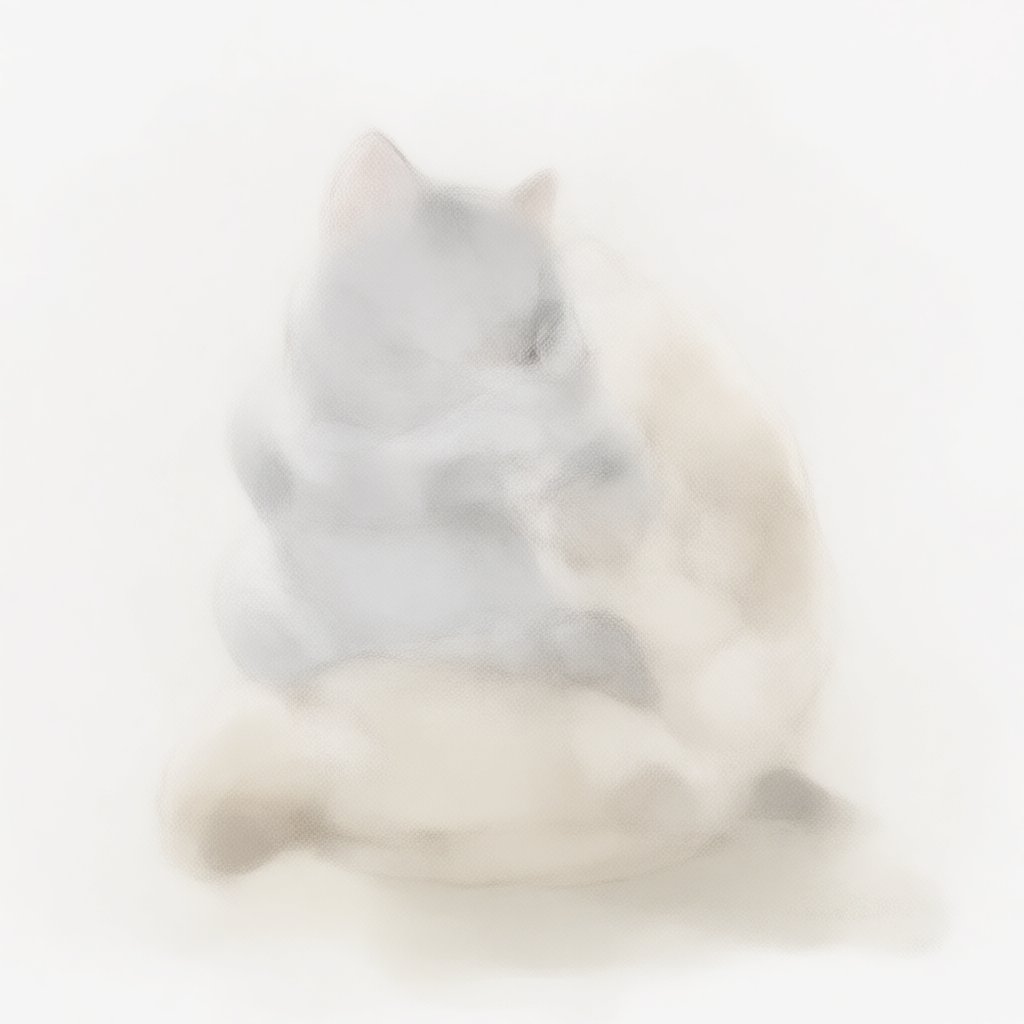

In [21]:
image = b2po.values["images"][0]
image